# Projet d'Ingénierie et d'Analyse de Données : Étude de la Chlordécone
## PARTIE 1 : Analyse Exploratoire des Données (EDA)

### 1. Importation des bibliothèques et chargement des données
Pour commencer, nous allons importer les outils nécessaires à notre analyse (pandas pour la manipulation, matplotlib et seaborn pour la visualisation). Ensuite, nous chargerons notre jeu de données.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#chargement des données
data = pd.read_csv('BaseCLD2026.csv',sep=';')

### 2. Identification des types de données
Conformément aux bonnes pratiques, notre première étape analytique consiste à observer la structure de notre jeu de données pour distinguer les **données quantitatives** (numériques) des **données qualitatives** (catégorielles). 

Nous allons afficher un aperçu des premières lignes et utiliser des fonctions pour lister les colonnes et leurs types respectifs.

In [4]:
data.head()

,ID,ANNEE,COMMU_LAB,RAIN,Sol_simple,type_sol,Date_prelevement,Date_enregistrement,Date_analyse,Operateur_chld,...,Taux_5b_hydro,histoBanane_Histo_ban,mnt_tpi_mean,mnt_tri_mean,mnt_rugosite_mean,mnt_ombrage_mean,mnt_exposition_mean,mnt_pente_mean,X,Y
0,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",2.0,5.805967,8.033367,21.593658,131.173998,79.447954,39.043098,714300.831892,1.626344e+06
1,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",2.0,5.683589,7.920563,20.944901,134.608205,76.985690,38.123675,714303.743345,1.626354e+06
2,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",3.0,2.239457,7.108432,20.085883,139.420523,76.064719,34.976678,714309.446765,1.626360e+06
3,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",1.0,4.038373,7.530090,23.427731,121.603678,92.392454,38.315796,714294.208512,1.626321e+06
4,20143,2010,GROS-MORNE,2000-3000,Andosol,Intergrades Sols … allophane relativement ‚vol...,24/05/2007,24/05/2007,24/05/2007,=,...,"0,07",2.0,0.596502,6.637082,20.153770,134.065066,83.930611,33.877727,714303.823058,1.626341e+06


In [6]:
data.dtypes

ID                         int64
ANNEE                      int64
COMMU_LAB                    str
RAIN                         str
Sol_simple                   str
type_sol                     str
Date_prelevement             str
Date_enregistrement          str
Date_analyse                 str
Operateur_chld               str
Taux_Chlordecone         float64
Operateur_5b                 str
Taux_5b_hydro                str
histoBanane_Histo_ban    float64
mnt_tpi_mean             float64
mnt_tri_mean             float64
mnt_rugosite_mean        float64
mnt_ombrage_mean         float64
mnt_exposition_mean      float64
mnt_pente_mean           float64
X                        float64
Y                        float64
dtype: object

In [7]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 31126 entries, 0 to 31125
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     31126 non-null  int64  
 1   ANNEE                  31126 non-null  int64  
 2   COMMU_LAB              30828 non-null  str    
 3   RAIN                   31126 non-null  str    
 4   Sol_simple             31052 non-null  str    
 5   type_sol               28517 non-null  str    
 6   Date_prelevement       31126 non-null  str    
 7   Date_enregistrement    31126 non-null  str    
 8   Date_analyse           31126 non-null  str    
 9   Operateur_chld         31126 non-null  str    
 10  Taux_Chlordecone       31126 non-null  float64
 11  Operateur_5b           31126 non-null  str    
 12  Taux_5b_hydro          31114 non-null  str    
 13  histoBanane_Histo_ban  13143 non-null  float64
 14  mnt_tpi_mean           31098 non-null  float64
 15  mnt_tri_mean 

In [8]:
data.describe()

,ID,ANNEE,Taux_Chlordecone,histoBanane_Histo_ban,mnt_tpi_mean,mnt_tri_mean,mnt_rugosite_mean,mnt_ombrage_mean,mnt_exposition_mean,mnt_pente_mean,X,Y
count,31126.000000,31126.000000,31126.000000,13143.000000,31098.000000,31098.000000,31098.000000,31098.000000,31098.000000,31098.000000,31126.000000,3.112600e+04
mean,38451.270449,2015.318994,0.667663,1.673286,0.211817,4.313287,13.444068,175.028425,170.170931,20.267107,713040.203783,1.624037e+06
std,19380.547105,2.816359,1.559895,0.732067,2.579504,2.858759,8.625712,27.893867,95.738110,13.373907,9887.780429,1.177384e+04
min,20003.000000,2010.000000,0.001000,1.000000,-29.065807,0.000000,0.000000,24.789383,0.000000,0.000000,690703.409647,1.594393e+06
25%,21868.000000,2013.000000,0.002400,1.000000,-0.875000,2.375000,7.500000,159.390883,89.758917,10.796759,703246.996817,1.614066e+06
50%,23412.000000,2016.000000,0.003300,2.000000,0.120032,3.821790,12.000000,177.102983,169.308929,17.902342,713492.101174,1.624496e+06
75%,62783.750000,2018.000000,0.410000,2.000000,1.266881,5.625000,17.764202,193.293212,249.271745,27.096912,721005.571086,1.633394e+06
max,63714.000000,2019.000000,17.350000,3.000000,26.011950,29.358208,85.396165,255.000000,359.144897,124.949989,734338.584306,1.645435e+06


### 3. Étude des statistiques descriptives 
À partir de notre premier aperçu, nous allons maintenant nous concentrer sur les indicateurs statistiques clés pour nos variables quantitatives (et tout particulièrement notre variable cible : `Taux_Chlordecone`) :

* **Valeurs extrêmes (Min/Max) et l'étendue** : Permet de connaître les limites de la série et de donner une première idée de la dispersion.
* **Le Mode** : La valeur la plus représentée, pour comprendre la distribution.
* **La Moyenne et la Médiane** : Ces deux indicateurs nous aident à voir la tendance centrale. Si la moyenne est très différente de la médiane, cela nous indique généralement une distribution asymétrique, souvent causée par des valeurs extrêmes (outliers).

*Remarque : La variable `Taux_5b_hydro` et les dates étant actuellement au format texte, nous les exclurons de ces calculs mathématiques pour l'instant et les traiterons dans la phase de nettoyage.*

In [9]:
#1.calcul de l'étendu (Max - Min)
val_max = data['Taux_Chlordecone'].max()
val_min = data['Taux_Chlordecone'].min()
etendue = val_max - val_min

print(f"Etendue du Taux de Chlordecone: {etendue}")

Etendue du Taux de Chlordecone: 17.349


In [10]:
# 2. calcul du Mode 
mode_taux = data['Taux_Chlordecone'].mode()[0]
print(f"Mode du Taux de Chlordecone: {mode_taux}")

Mode du Taux de Chlordecone: 0.0033


In [12]:
#3. calcul de la moyenne et de la médiane 
moyenne_taux = data['Taux_Chlordecone'].mean()
mediane_taux = data['Taux_Chlordecone'].median()

print(f"Moyenne du Taux de Chlordecone: {moyenne_taux:.4f}")
print(f"Médiane du Taux de Chlordecone: {mediane_taux:.4f}")

Moyenne du Taux de Chlordecone: 0.6677
Médiane du Taux de Chlordecone: 0.0033


### 4. Interprétation des statistiques descriptives
L'analyse des indicateurs de base pour notre variable cible `Taux_Chlordecone` nous a donné les résultats suivants :
* **Étendue** : 17.349 (montrant une large plage de valeurs possibles).
* **Mode** : 0.0033 (la valeur la plus fréquente est très faible).
* **Moyenne vs Médiane** : La moyenne (0.667) est largement supérieure à la médiane (0.0033). 

**Conclusion :** Ce fort déséquilibre indique une distribution très asymétrique. La majorité des prélèvements présente un taux très faible de chlordécone, mais la moyenne est tirée vers le haut par la présence probable de **valeurs extrêmes (valeurs aberrantes)** très élevées.

---

### 5. Visualisation de la distribution (Manuel de Rony)
Pour confirmer notre constat sur les valeurs extrêmes et mieux appréhender la répartition du `Taux_Chlordecone`. 

Nous allons tracer pour notre variable quantitative une colonne :
1. Un **Histogramme** pour visualiser la forme de la distribution et l'écrasement des valeurs.
2. Un **Box plot (Boîte à moustaches)** qui est l'outil parfait pour repérer visuellement les valeurs aberrantes au-delà des quartiles.


In [13]:
#configuration du style visuel
sns.set_style('whitegrid')

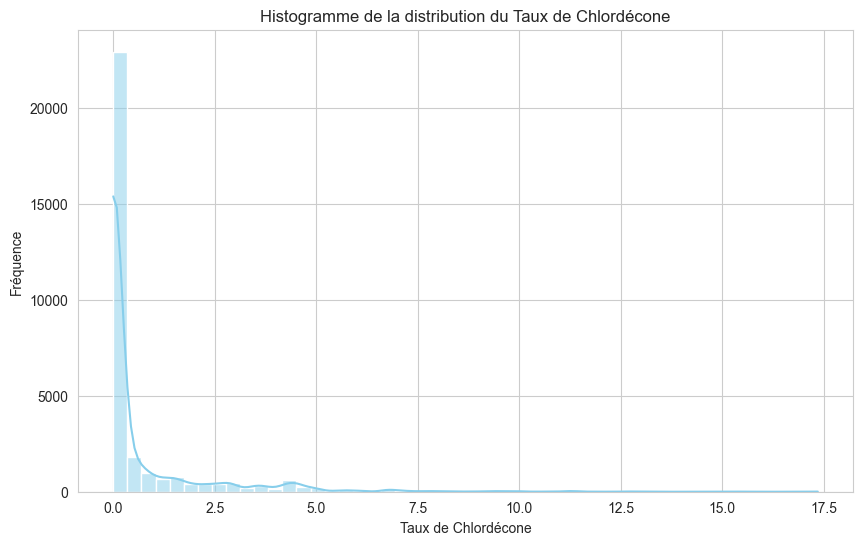

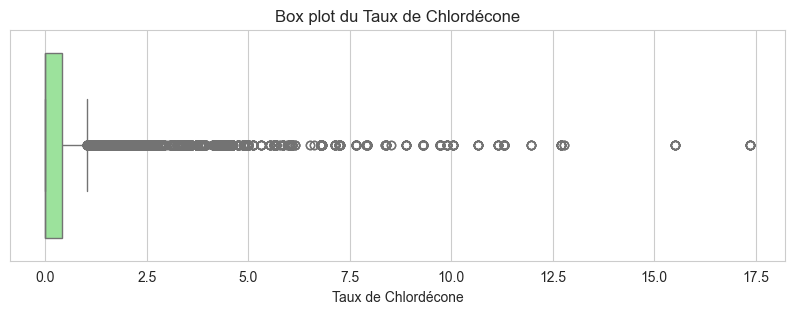

In [17]:
# 1. Histogramme seul (plus grand)
plt.figure(figsize=(10, 6))
sns.histplot(data['Taux_Chlordecone'], bins=50, kde=True, color='skyblue')
plt.title('Histogramme de la distribution du Taux de Chlordécone')
plt.xlabel('Taux de Chlordécone')
plt.ylabel('Fréquence')
plt.show()

# 2. Box plot seul (format horizontal, adapté pour voir les valeurs extrêmes)
plt.figure(figsize=(10, 3))
sns.boxplot(x=data['Taux_Chlordecone'], color='lightgreen')
plt.title('Box plot du Taux de Chlordécone')
plt.xlabel('Taux de Chlordécone')
plt.show()

### 6. Conclusions de la visualisation du Taux de Chlordécone
Les graphiques confirment parfaitement notre analyse statistique :
* **L'histogramme** montre un pic massif très proche de 0, indiquant que la vaste majorité des prélèvements présente une contamination faible. La courbe chute ensuite drastiquement.
* **Le Box plot** est complètement écrasé sur la gauche (la boîte se situe environ entre 0.0 et 0.4). L'immense majorité de l'étendue visuelle est constituée de points isolés.

**Conclusion :** Ces points représentent les **valeurs extrêmes (outliers)**. Dans notre contexte, ce ne sont pas forcément des erreurs de mesure, mais potentiellement des parcelles ("points chauds") extrêmement contaminées. Nous devrons décider comment les traiter lors de la phase de nettoyage.

---

### 7. Exploration des variables qualitatives
Nous allons créer un diagramme en barres pour observer la répartition de nos prélèvements en fonction du type de sol (`Sol_simple`). Cela nous permettra de voir si nos données sont équilibrées ou si un type de sol est surreprésenté dans l'étude.

J'ai choisi la variable Sol_simple (le type de sol) car c'est une donnée agronomique très importante dans l'étude de la chlordécone.

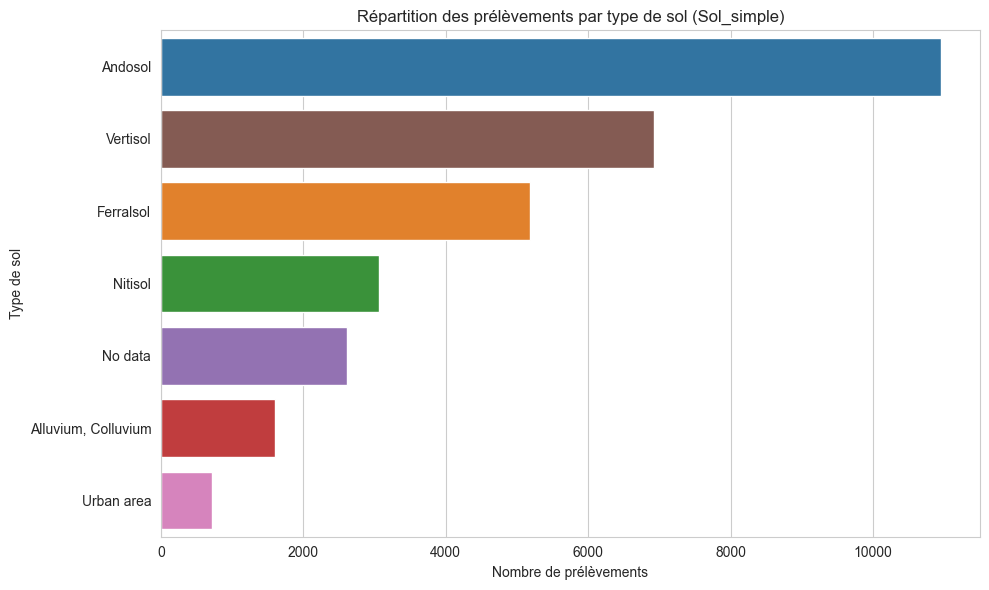

In [18]:
plt.figure(figsize=(10, 6))

#création du diagramme en barre ( par odre croissant )
sns.countplot(
    data=data,
    y='Sol_simple',
    hue='Sol_simple',
    order=data['Sol_simple'].value_counts().index,
    legend=False
)


plt.title('Répartition des prélèvements par type de sol (Sol_simple)')
plt.xlabel('Nombre de prélèvements')
plt.ylabel('Type de sol')

plt.tight_layout()
plt.show()


### 8. Conclusions sur les variables qualitatives
L'analyse du type de sol (`Sol_simple`) révèle que les prélèvements sont majoritairement concentrés sur quatre types de sols : **Andosol, Vertisol, Ferralsol et Nitisol**. 

Cependant, nous avons identifié une catégorie "no data" (ou équivalent) très représentée, presque au même niveau que les Nitisols. Cela confirme que notre jeu de données brut contient des imperfections qui devront être traitées.